In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# @title Default title text
df = pd.read_csv("/content/drive/MyDrive/Diabetes_cdc/2015_dataset/diabetes_012_health_indicators_BRFSS2015.csv")
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


In [ ]:
df.info()
df.Age.unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Diabetes_012          253680 non-null  int64
 1   HighBP                253680 non-null  int64
 2   HighChol              253680 non-null  int64
 3   CholCheck             253680 non-null  int64
 4   BMI                   253680 non-null  int64
 5   Smoker                253680 non-null  int64
 6   Stroke                253680 non-null  int64
 7   HeartDiseaseorAttack  253680 non-null  int64
 8   PhysActivity          253680 non-null  int64
 9   Fruits                253680 non-null  int64
 10  Veggies               253680 non-null  int64
 11  HvyAlcoholConsump     253680 non-null  int64
 12  AnyHealthcare         253680 non-null  int64
 13  NoDocbcCost           253680 non-null  int64
 14  GenHlth               253680 non-null  int64
 15  MentHlth              253680 non-n

array([ 9,  7, 11, 10,  8, 13,  4,  6,  2, 12,  5,  1,  3])

In [ ]:

# Categorical columns
categorical_cols = ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
                   'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump',
                   'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex']

# Continuous columns
discrete_continuous_cols = ['BMI', 'Age', 'MentHlth', 'PhysHlth', 'Income', 'Education']


In [ ]:
def univariate_categorical_analysis(df, columns):
  # numerical analysis
  print(f"Descriptive Statistics for {columns}")
  print(df[columns].value_counts(), df[columns].value_counts(normalize=True).round(2))
  # print(df[columns].describe())

  # graphical analysis
  fig, axes = plt.subplots(1, 2, figsize=(10, 4))
  # bar chart
  sns.countplot(x=df[columns], ax=axes[0])
  axes[0].set_title(f"{columns} Distribution (Bar Chart)")

  # pie chart
  df[columns].value_counts().plot.pie(autopct="%1.1f%%", ax=axes[1])
  axes[1].set_title(f"{columns} Distribution (Pie Chart)")
  plt.show()


  # testing of hypothesis

def univariate_continuous_analysis(df, columns):
  print("-" * 50)
  '''Numerical Analysis'''
  print(f"Statistical Summary for {columns}")
  print(df[columns].describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(2))
  Q1 = df[columns].quantile(0.25)
  Q3 = df[columns].quantile(0.75)
  IQR = Q3 - Q1
  print(f"IQR: {IQR}")
  print(f"Skewness: {df[columns].skew().round(2)}")
  print(f"Kurtosis: {df[columns].kurt().round(2)}")

  # Shape of distribution
  print("\nShape of Distribution:")
  print(f"Skewness: {df[columns].skew().round(2)}")
  print(f"Kurtosis: {df[columns].kurt().round(2)}")

  '''Graphical analysis'''
  plt.figure(figsize=(15, 5))

  # Histogram
  plt.subplot(131)
  sns.histplot(df[columns], kde=False)
  plt.title(f"Histogram of {columns}")

  # Box plot
  plt.subplot(132)
  sns.boxplot(y=df[columns])
  plt.title(f"Box Plot of {columns}")

  # Violin plot
  plt.subplot(133)
  sns.violinplot(y=df[columns])
  plt.title(f"Violin Plot of {columns}")

  plt.tight_layout()
  plt.show()

  '''testing of hypothesis'''
  # Normality Test
  print("\nNormality Test:")
  print(f"Shapiro-Wilk Test: {stats.shapiro(df[columns])}")
  print(f"D'Agostino's K^2 Test: {stats.normaltest(df[columns])}")
  # q-q plot
  plt.figure(figsize=(5, 5))
  stats.probplot(df[columns], dist="norm", plot=plt)
  plt.title(f"Q-Q Plot of {columns}")
  plt.show()



Descriptive Statistics for Diabetes_012
Diabetes_012
0    213703
2     35346
1      4631
Name: count, dtype: int64 Diabetes_012
0    0.84
2    0.14
1    0.02
Name: proportion, dtype: float64


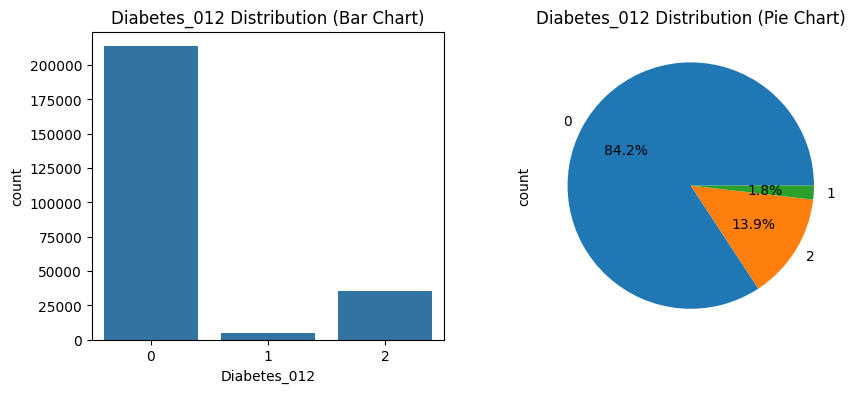

Descriptive Statistics for HighBP
HighBP
0    144851
1    108829
Name: count, dtype: int64 HighBP
0    0.57
1    0.43
Name: proportion, dtype: float64


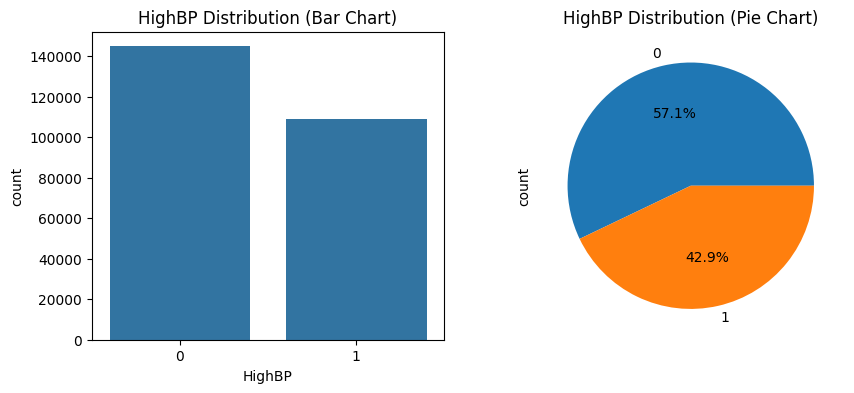

Descriptive Statistics for HighChol
HighChol
0    146089
1    107591
Name: count, dtype: int64 HighChol
0    0.58
1    0.42
Name: proportion, dtype: float64


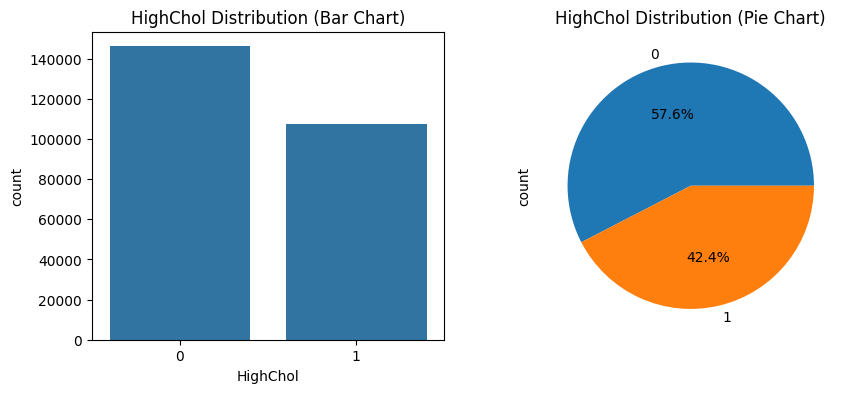

Descriptive Statistics for CholCheck
CholCheck
1    244210
0      9470
Name: count, dtype: int64 CholCheck
1    0.96
0    0.04
Name: proportion, dtype: float64


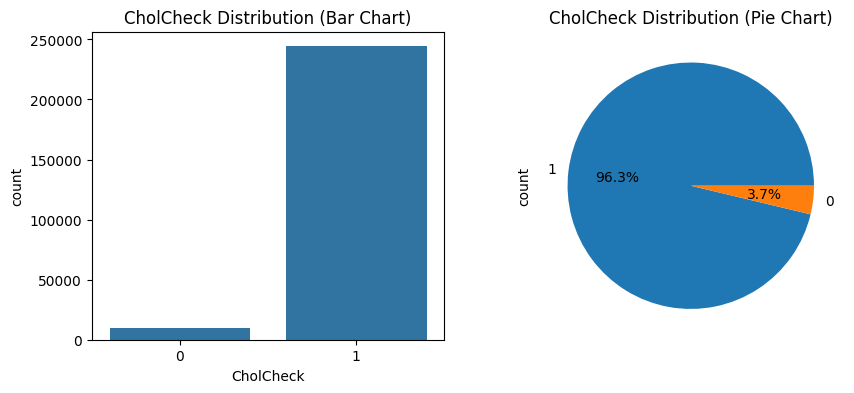

--------------------------------------------------
Statistical Summary for BMI
count    253680.00
mean         28.38
std           6.61
min          12.00
5%           20.00
25%          24.00
50%          27.00
75%          31.00
95%          40.00
99%          50.00
max          98.00
Name: BMI, dtype: float64
IQR: 7.0
Skewness: 2.12
Kurtosis: 11.0

Shape of Distribution:
Skewness: 2.12
Kurtosis: 11.0


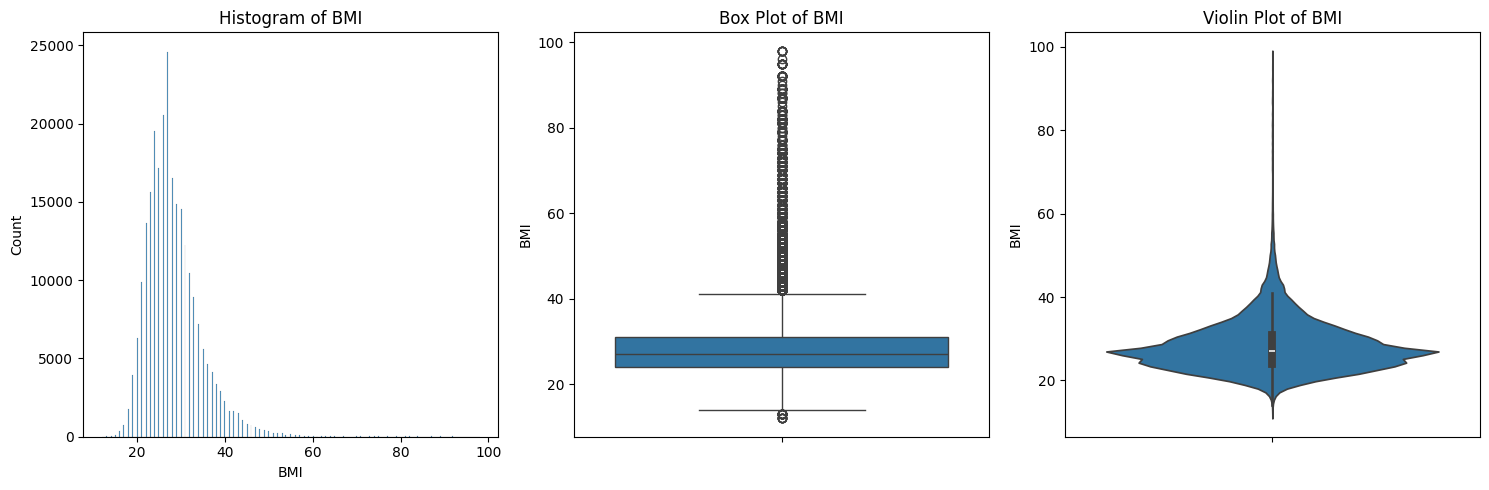


Normality Test:
Shapiro-Wilk Test: ShapiroResult(statistic=0.8716523820866171, pvalue=2.8075041639018313e-139)
D'Agostino's K^2 Test: NormaltestResult(statistic=126255.71853500305, pvalue=0.0)


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 253680.
  res = hypotest_fun_out(*samples, **kwds)


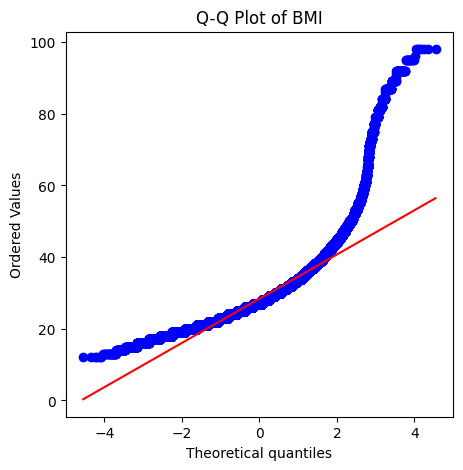

Descriptive Statistics for Smoker
Smoker
0    141257
1    112423
Name: count, dtype: int64 Smoker
0    0.56
1    0.44
Name: proportion, dtype: float64


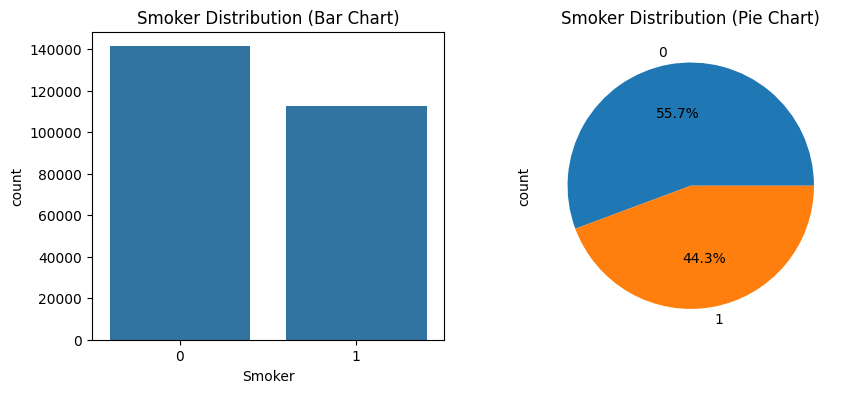

Descriptive Statistics for Stroke
Stroke
0    243388
1     10292
Name: count, dtype: int64 Stroke
0    0.96
1    0.04
Name: proportion, dtype: float64


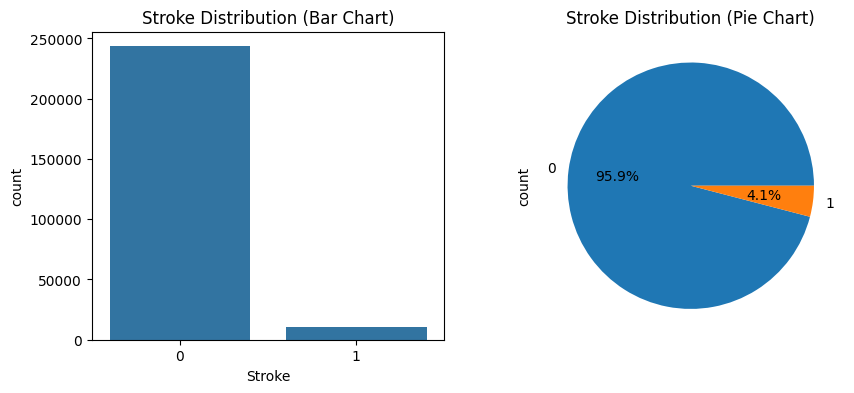

Descriptive Statistics for HeartDiseaseorAttack
HeartDiseaseorAttack
0    229787
1     23893
Name: count, dtype: int64 HeartDiseaseorAttack
0    0.91
1    0.09
Name: proportion, dtype: float64


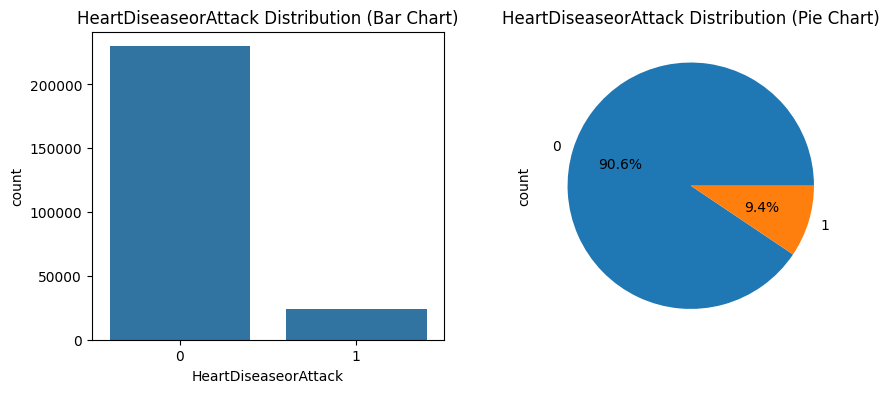

Descriptive Statistics for PhysActivity
PhysActivity
1    191920
0     61760
Name: count, dtype: int64 PhysActivity
1    0.76
0    0.24
Name: proportion, dtype: float64


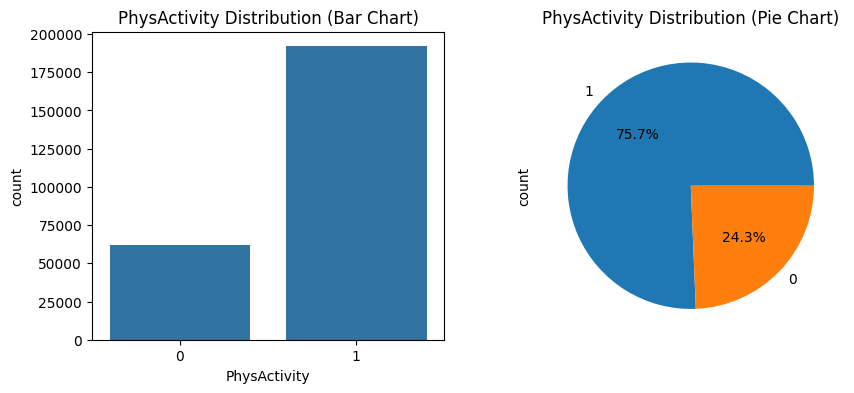

Descriptive Statistics for Fruits
Fruits
1    160898
0     92782
Name: count, dtype: int64 Fruits
1    0.63
0    0.37
Name: proportion, dtype: float64


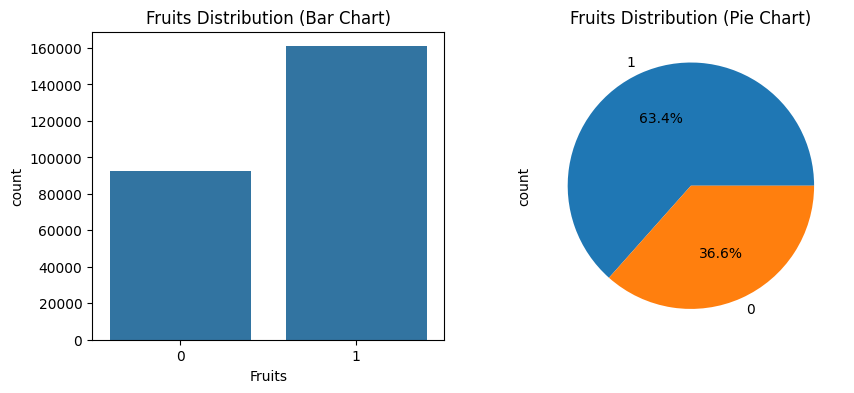

Descriptive Statistics for Veggies
Veggies
1    205841
0     47839
Name: count, dtype: int64 Veggies
1    0.81
0    0.19
Name: proportion, dtype: float64


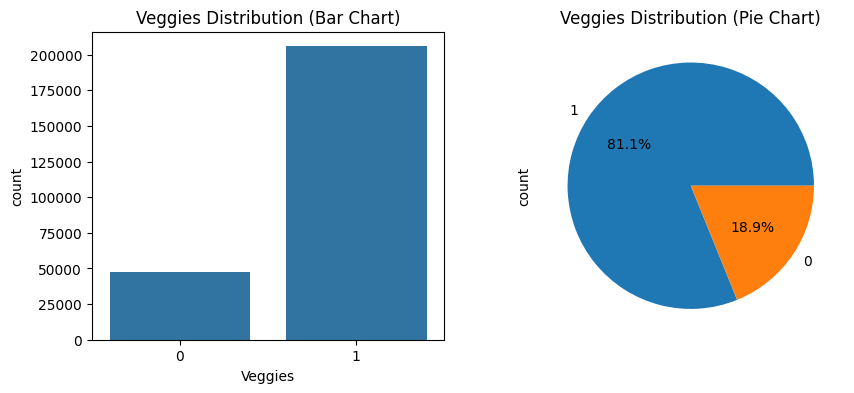

Descriptive Statistics for HvyAlcoholConsump
HvyAlcoholConsump
0    239424
1     14256
Name: count, dtype: int64 HvyAlcoholConsump
0    0.94
1    0.06
Name: proportion, dtype: float64


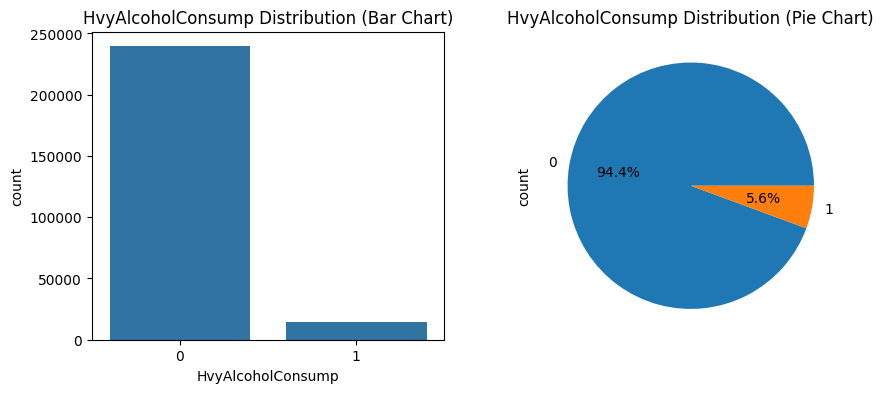

Descriptive Statistics for AnyHealthcare
AnyHealthcare
1    241263
0     12417
Name: count, dtype: int64 AnyHealthcare
1    0.95
0    0.05
Name: proportion, dtype: float64


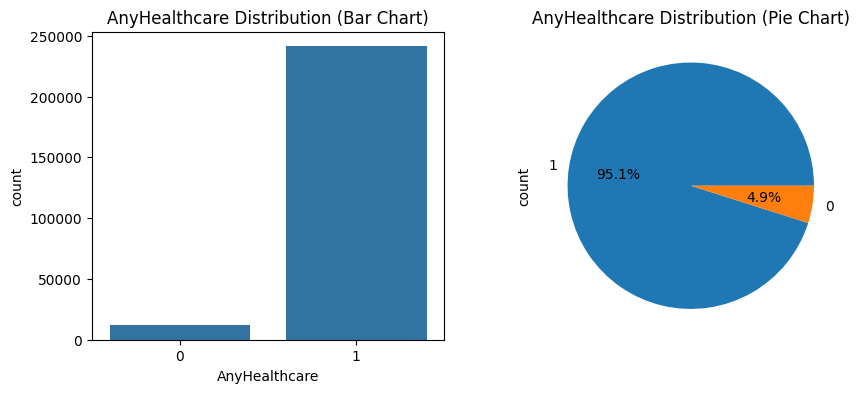

Descriptive Statistics for NoDocbcCost
NoDocbcCost
0    232326
1     21354
Name: count, dtype: int64 NoDocbcCost
0    0.92
1    0.08
Name: proportion, dtype: float64


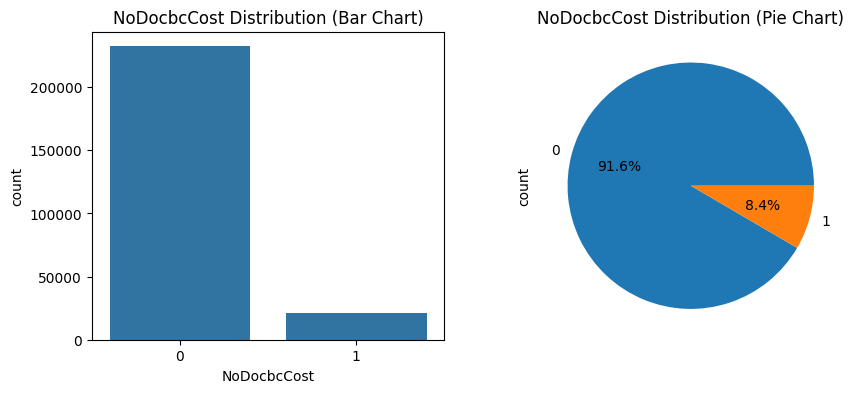

Descriptive Statistics for GenHlth
GenHlth
2    89084
3    75646
1    45299
4    31570
5    12081
Name: count, dtype: int64 GenHlth
2    0.35
3    0.30
1    0.18
4    0.12
5    0.05
Name: proportion, dtype: float64


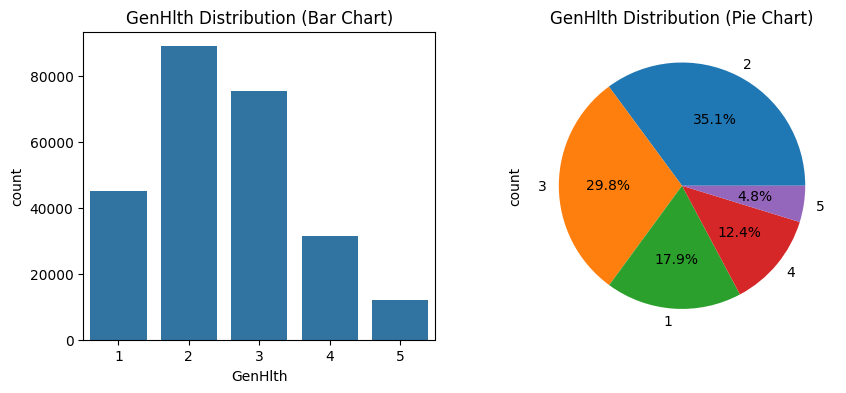

--------------------------------------------------
Statistical Summary for MentHlth
count    253680.00
mean          3.18
std           7.41
min           0.00
5%            0.00
25%           0.00
50%           0.00
75%           2.00
95%          26.00
99%          30.00
max          30.00
Name: MentHlth, dtype: float64
IQR: 2.0
Skewness: 2.72
Kurtosis: 6.44

Shape of Distribution:
Skewness: 2.72
Kurtosis: 6.44


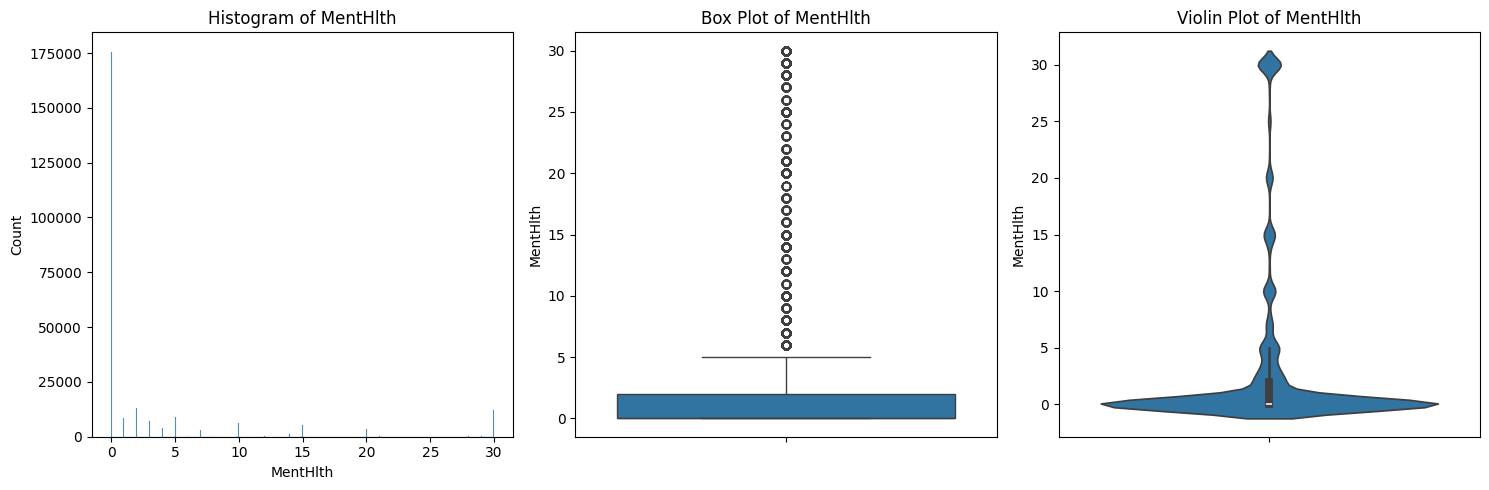


Normality Test:
Shapiro-Wilk Test: ShapiroResult(statistic=0.4869121052555616, pvalue=2.1173563779429958e-185)
D'Agostino's K^2 Test: NormaltestResult(statistic=137190.85980080973, pvalue=0.0)


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 253680.
  res = hypotest_fun_out(*samples, **kwds)


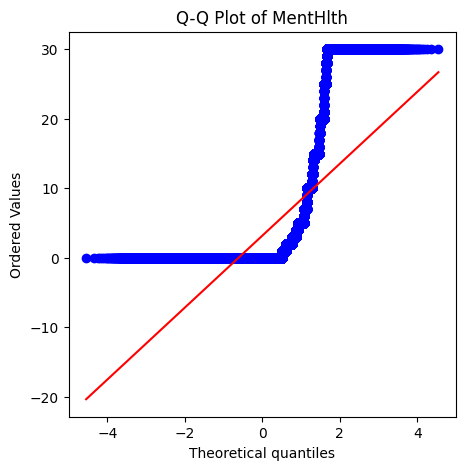

--------------------------------------------------
Statistical Summary for PhysHlth
count    253680.00
mean          4.24
std           8.72
min           0.00
5%            0.00
25%           0.00
50%           0.00
75%           3.00
95%          30.00
99%          30.00
max          30.00
Name: PhysHlth, dtype: float64
IQR: 3.0
Skewness: 2.21
Kurtosis: 3.5

Shape of Distribution:
Skewness: 2.21
Kurtosis: 3.5


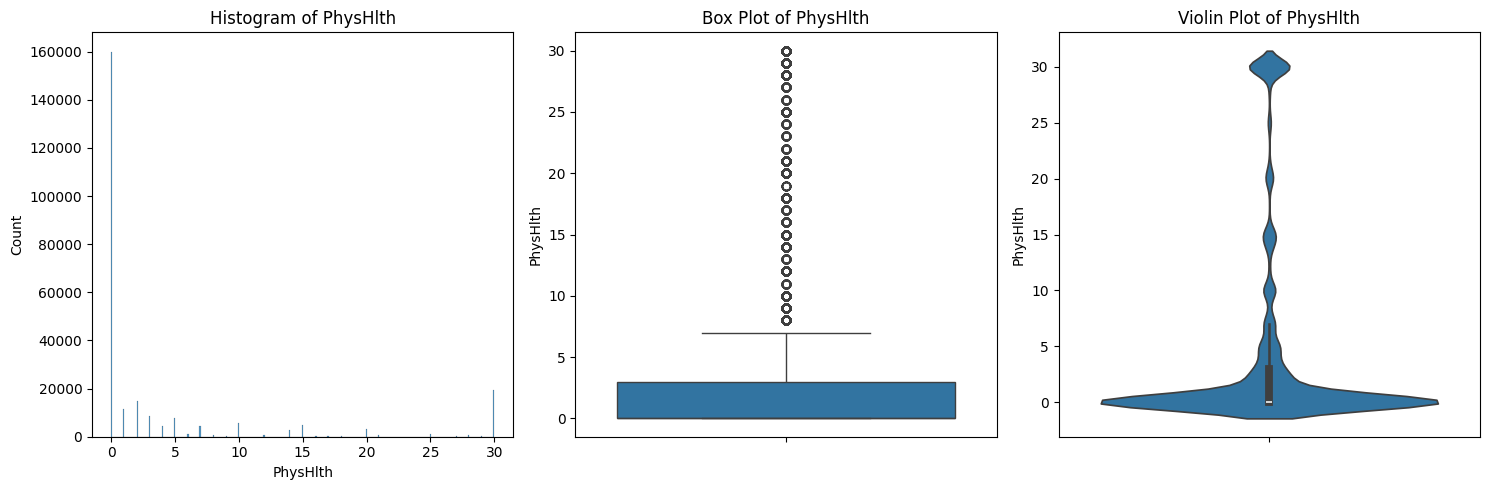


Normality Test:
Shapiro-Wilk Test: ShapiroResult(statistic=0.5384921460687035, pvalue=1.2233049705533403e-181)
D'Agostino's K^2 Test: NormaltestResult(statistic=104008.51633122214, pvalue=0.0)


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 253680.
  res = hypotest_fun_out(*samples, **kwds)


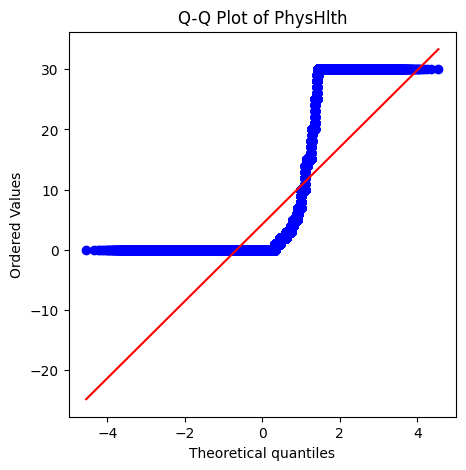

Descriptive Statistics for DiffWalk
DiffWalk
0    211005
1     42675
Name: count, dtype: int64 DiffWalk
0    0.83
1    0.17
Name: proportion, dtype: float64


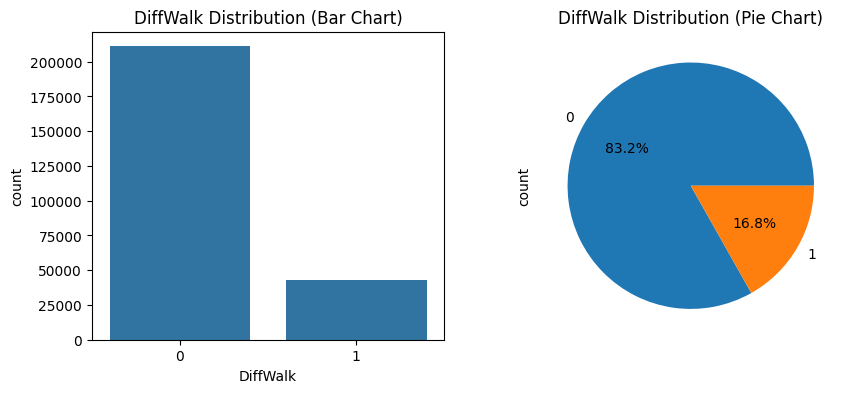

Descriptive Statistics for Sex
Sex
0    141974
1    111706
Name: count, dtype: int64 Sex
0    0.56
1    0.44
Name: proportion, dtype: float64


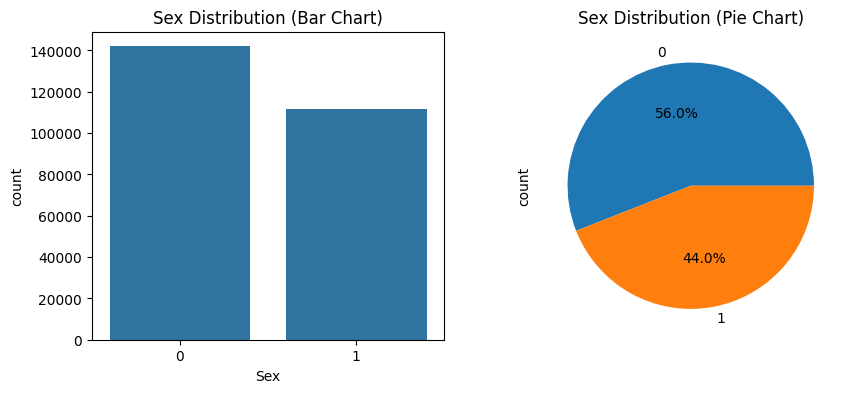

--------------------------------------------------
Statistical Summary for Age
count    253680.00
mean          8.03
std           3.05
min           1.00
5%            2.00
25%           6.00
50%           8.00
75%          10.00
95%          13.00
99%          13.00
max          13.00
Name: Age, dtype: float64
IQR: 4.0
Skewness: -0.36
Kurtosis: -0.58

Shape of Distribution:
Skewness: -0.36
Kurtosis: -0.58


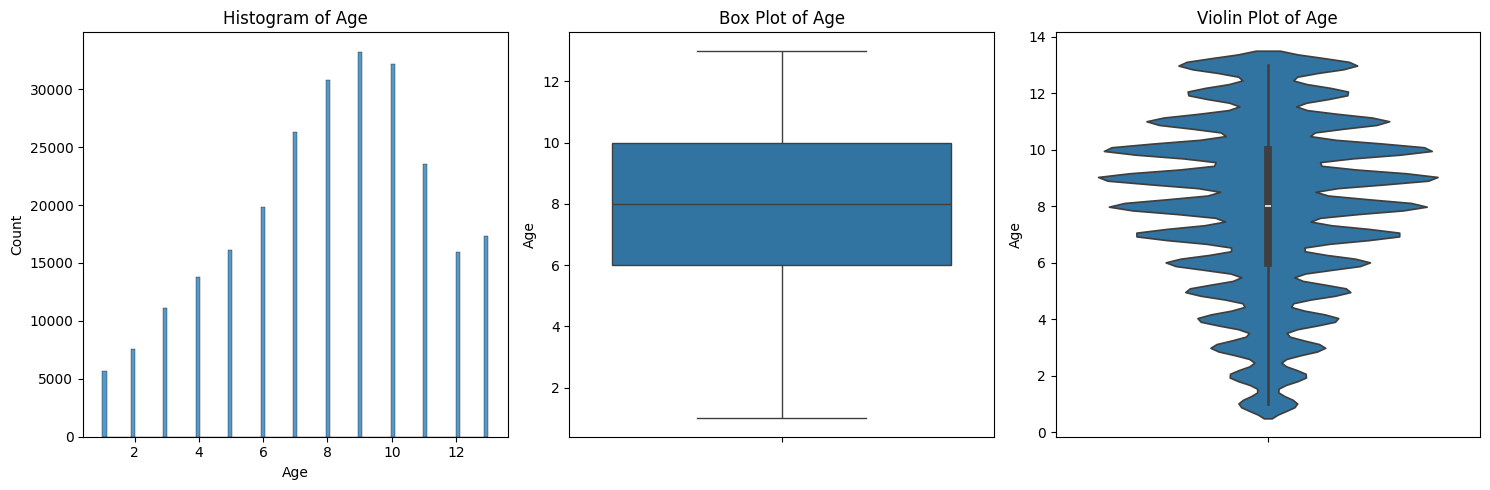


Normality Test:
Shapiro-Wilk Test: ShapiroResult(statistic=0.964681492566685, pvalue=2.5444298490918793e-102)
D'Agostino's K^2 Test: NormaltestResult(statistic=12632.013194385043, pvalue=0.0)


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 253680.
  res = hypotest_fun_out(*samples, **kwds)


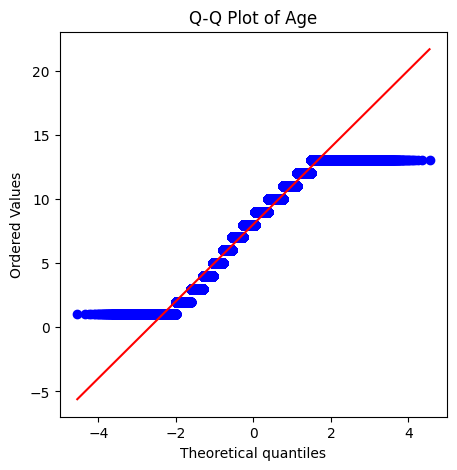

--------------------------------------------------
Statistical Summary for Education
count    253680.00
mean          5.05
std           0.99
min           1.00
5%            3.00
25%           4.00
50%           5.00
75%           6.00
95%           6.00
99%           6.00
max           6.00
Name: Education, dtype: float64
IQR: 2.0
Skewness: -0.78
Kurtosis: 0.04

Shape of Distribution:
Skewness: -0.78
Kurtosis: 0.04


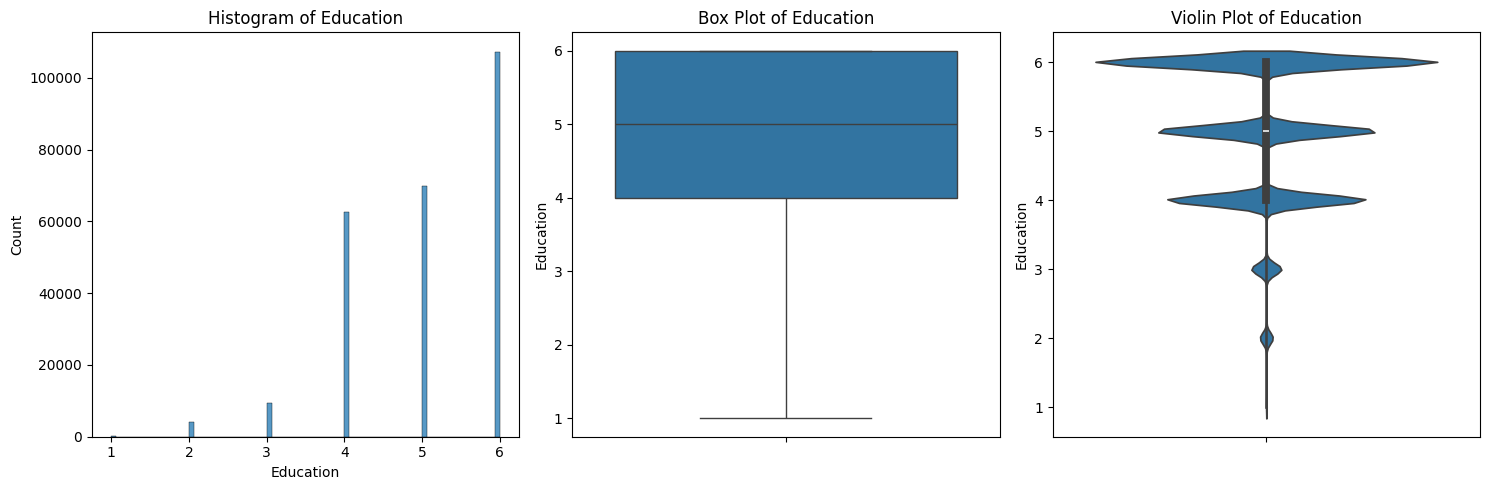


Normality Test:
Shapiro-Wilk Test: ShapiroResult(statistic=0.8210975372639714, pvalue=1.004090532226038e-149)
D'Agostino's K^2 Test: NormaltestResult(statistic=20237.520860382563, pvalue=0.0)


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 253680.
  res = hypotest_fun_out(*samples, **kwds)


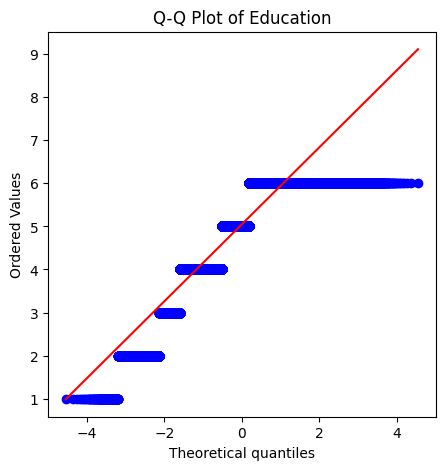

--------------------------------------------------
Statistical Summary for Income
count    253680.00
mean          6.05
std           2.07
min           1.00
5%            2.00
25%           5.00
50%           7.00
75%           8.00
95%           8.00
99%           8.00
max           8.00
Name: Income, dtype: float64
IQR: 3.0
Skewness: -0.89
Kurtosis: -0.28

Shape of Distribution:
Skewness: -0.89
Kurtosis: -0.28


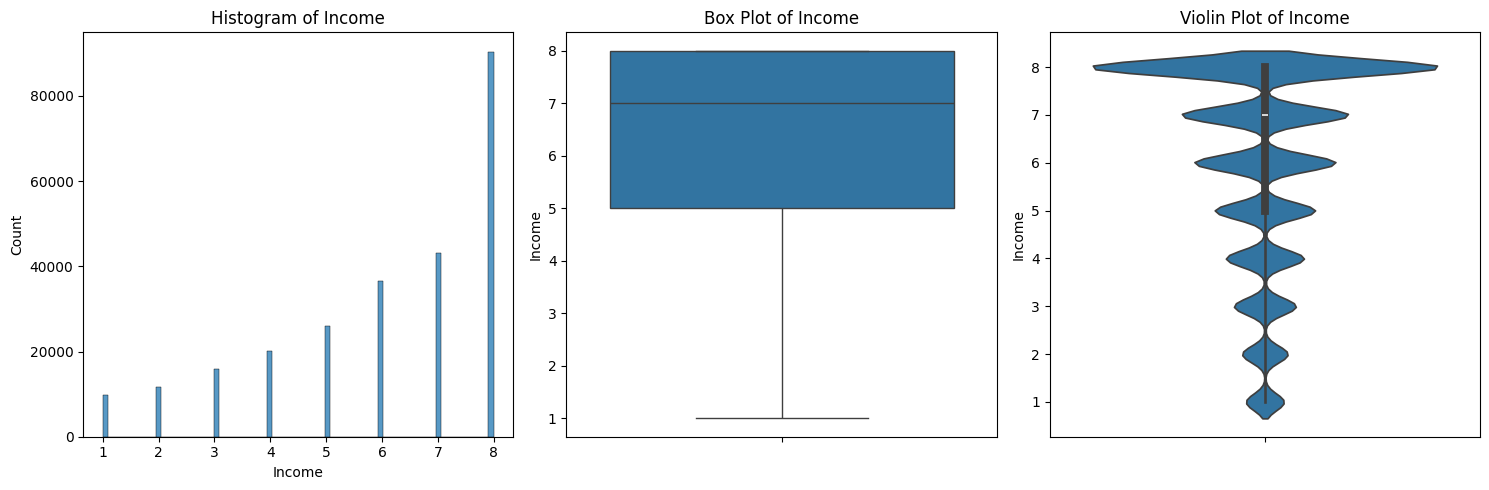


Normality Test:
Shapiro-Wilk Test: ShapiroResult(statistic=0.8464267632853055, pvalue=7.104015319145788e-145)
D'Agostino's K^2 Test: NormaltestResult(statistic=26291.787159451822, pvalue=0.0)


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 253680.
  res = hypotest_fun_out(*samples, **kwds)


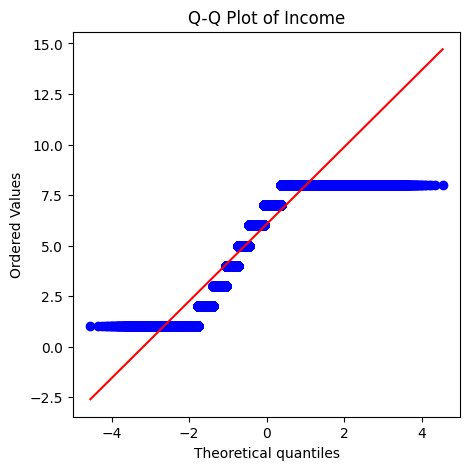

In [ ]:
for columns in df.columns:
  if columns in categorical_cols:
    univariate_categorical_analysis(df, columns)
  else:
    univariate_continuous_analysis(df, columns)


Univariate of target variable

Diabetes_012
0    213703
2     35346
1      4631
Name: count, dtype: int64
Diabetes_012
0    84.24%
2    13.93%
1     1.83%
Name: proportion, dtype: object


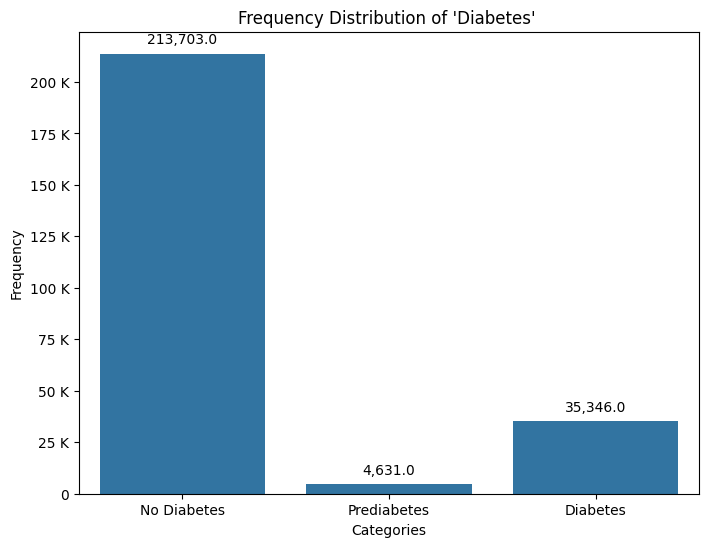

In [ ]:
# Re-run the numerical analysis without trying to save the output
# Frequency count of each category
frequency = df['Diabetes_012'].value_counts()
print(frequency)
# Proportions of each category
# proportions = df['Diabetes_012'].value_counts(normalize=True) * 100
proportions = df['Diabetes_012'].value_counts(normalize=True) * 100
formatted_proportions = proportions.apply(lambda x: f'{x:.2f}%')
print(formatted_proportions)

# Mode of the Diabetes_012 (most frequent value)
# mode = df['Diabetes_012'].mode()[0]

# Display the results



plt.figure(figsize=(8, 6))  # Adjust figure size if needed
sns.countplot(x='Diabetes_012', data=df)
plt.title("Frequency Distribution of 'Diabetes' ")
plt.xlabel('Categories')
plt.ylabel('Frequency')
plt.xticks([0, 1, 2], ['No Diabetes', 'Prediabetes', 'Diabetes'])
import matplotlib.ticker as ticker

# ... your existing code ...

def format_indian_rupees(value, pos):
    """Formats a value into Indian Rupees format."""
    value = int(value)  # Convert to integer
    # if value >= 10000000:
    #     return f'{value / 10000000:.0f} Cr'
    # elif value >= 100000:
    #     return f'{value / 100000:.0f} Lac'
    if value >= 1000:
        return f'{value / 1000:.0f} K'
    else:
        return str(value)

# ... your existing code ...

# Format y-axis ticks
ax = plt.gca()  # Get current axes
ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_indian_rupees))

for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()


##Bivariate Analysis

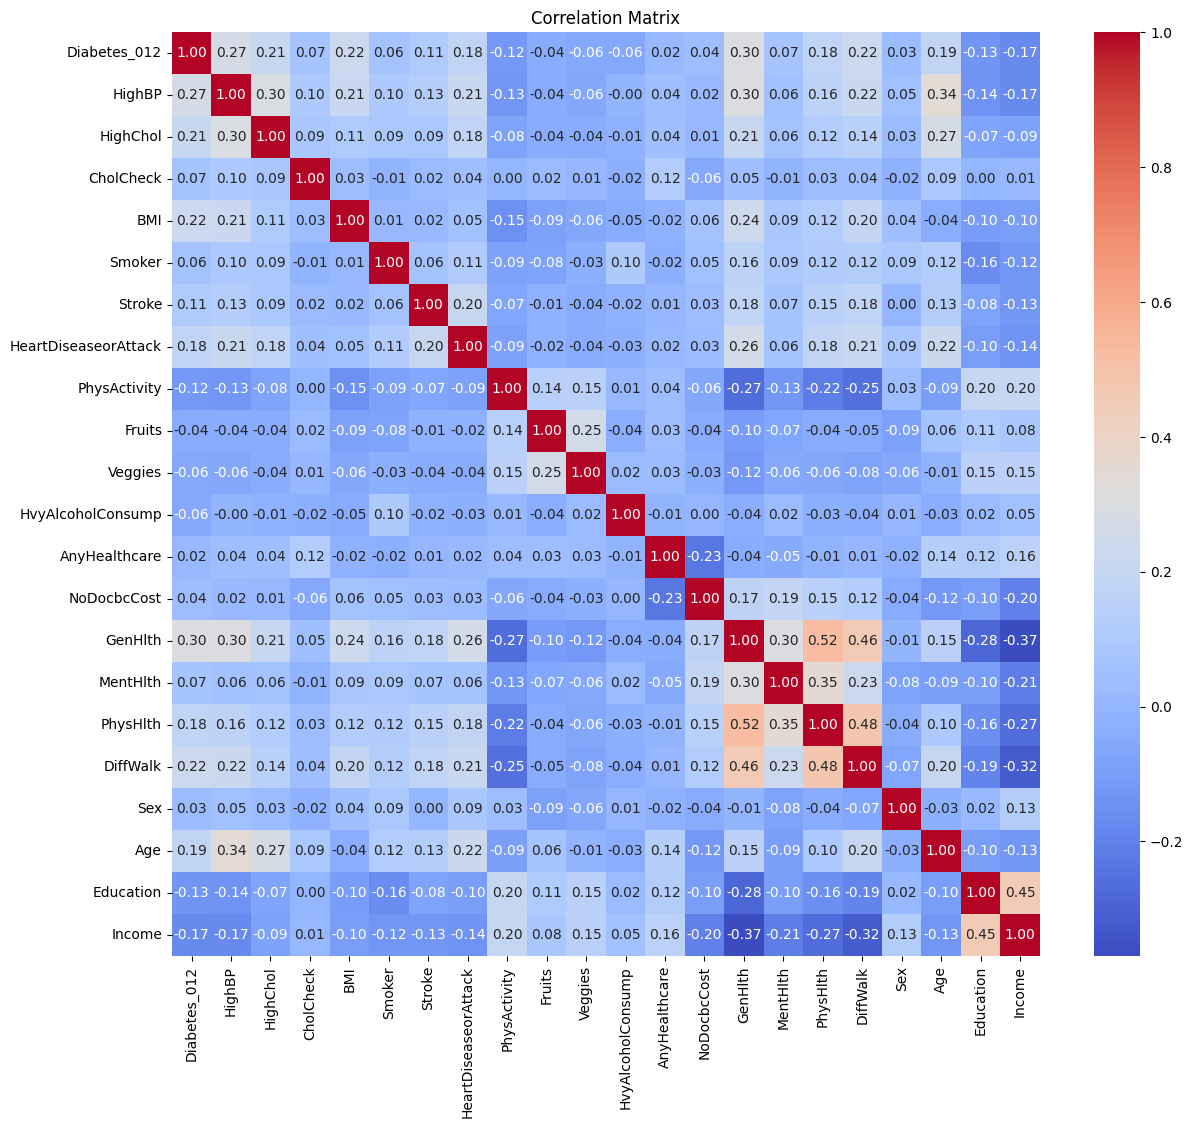

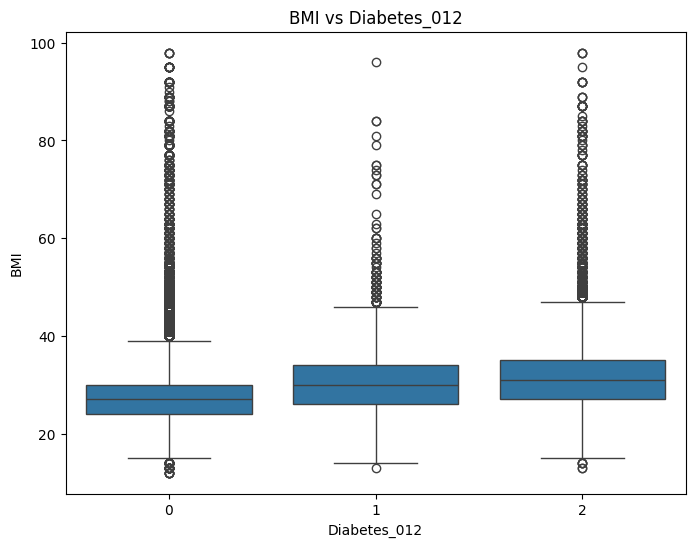

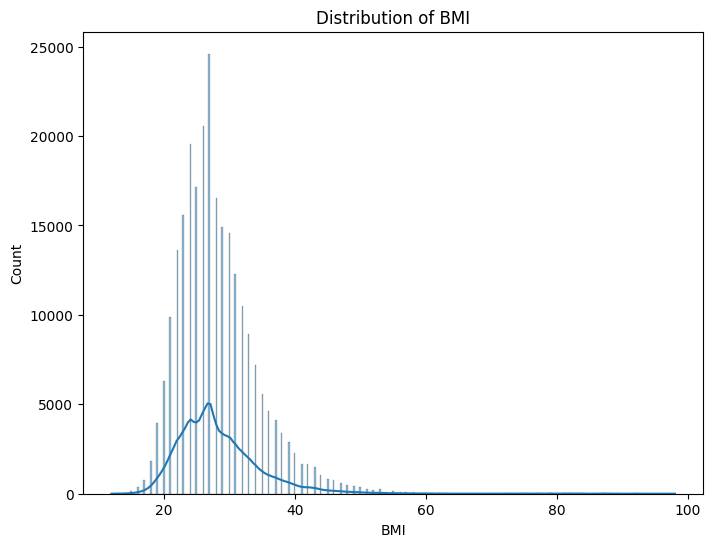

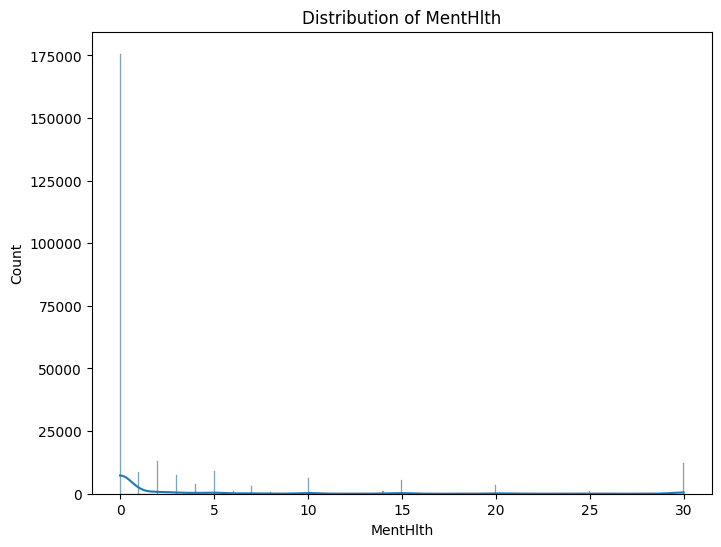

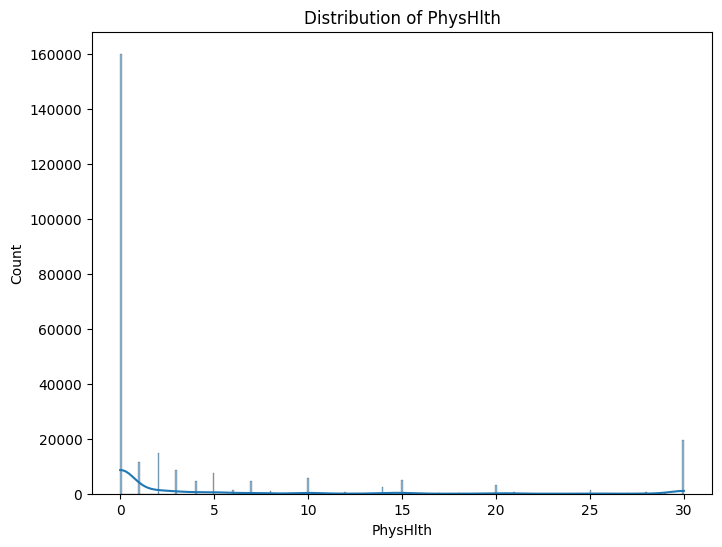

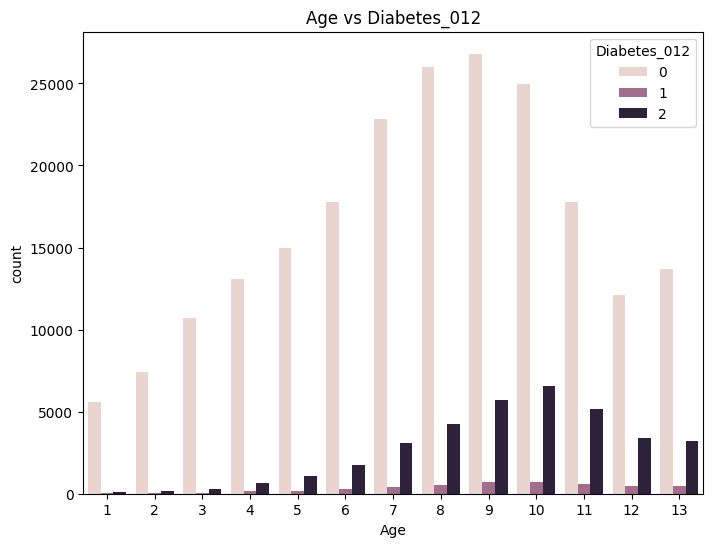

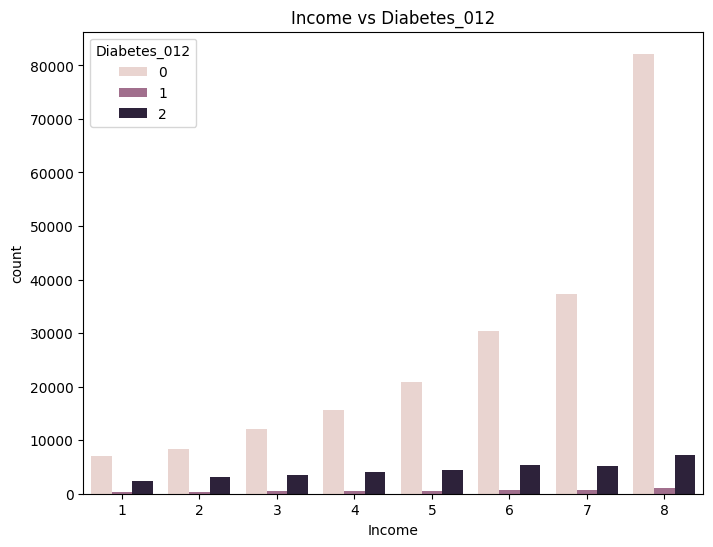

In [ ]:
# Correlation Analysis
correlation_matrix = df.corr()

# Plotting the correlation matrix
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Visualizations for key health indicators
# Plotting the relationship between BMI and Diabetes
plt.figure(figsize=(8, 6))
sns.boxplot(x='Diabetes_012', y='BMI', data=df)
plt.title('BMI vs Diabetes_012')
plt.show()

# Distribution Analysis for continuous variables
# Plotting the distribution of BMI
plt.figure(figsize=(8, 6))
sns.histplot(df['BMI'], kde=True)
plt.title('Distribution of BMI')
plt.show()

# Plotting the distribution of MentHlth
plt.figure(figsize=(8, 6))
sns.histplot(df['MentHlth'], kde=True)
plt.title('Distribution of MentHlth')
plt.show()

# Plotting the distribution of PhysHlth
plt.figure(figsize=(8, 6))
sns.histplot(df['PhysHlth'], kde=True)
plt.title('Distribution of PhysHlth')
plt.show()

# Demographic Analysis
# Plotting the relationship between Age and Diabetes
plt.figure(figsize=(8, 6))
sns.countplot(x='Age', hue='Diabetes_012', data=df)
plt.title('Age vs Diabetes_012')
plt.show()

# Plotting the relationship between Income and Diabetes
plt.figure(figsize=(8, 6))
sns.countplot(x='Income', hue='Diabetes_012', data=df)
plt.title('Income vs Diabetes_012')
plt.show()

In [ ]:
# 4. Bivariate Analysis
print("\n4. Bivariate Analysis")

def bivariate_analysis(df, column, target='Diabetes_012'):
    print(f"\nBivariate Analysis: {column} vs {target}")
    print("-" * 50)

    if df[column].dtype in ['int64', 'float64']:
        # Correlation
        correlation = stats.pointbiserialr(df[target], df[column])
        print(f"Point Biserial Correlation: {correlation.correlation:.4f}")
        print(f"P-value: {correlation.pvalue:.4f}")

        # Visualization
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=target, y=column, data=df)
        plt.title(f"{column} vs {target}")
        plt.savefig(f"bivariate_{column}_vs_{target}.png")
        plt.close()

    else:
        # Contingency Table
        cont_table = pd.crosstab(df[column], df[target])
        print("Contingency Table:")
        print(cont_table)

        # Chi-Square Test
        chi2, p_value, dof, expected = stats.chi2_contingency(cont_table)
        print(f"\nChi-Square Test p-value: {p_value:.4f}")

        # Visualization
        plt.figure(figsize=(10, 6))
        sns.countplot(x=column, hue=target, data=df)
        plt.title(f"{column} vs {target}")
        plt.savefig(f"bivariate_{column}_vs_{target}.png")
        plt.close()

# Perform bivariate analysis for each column
for column in df.columns:
    if column != 'Diabetes_012':
        bivariate_analysis(df, column)

# 5. Correlation Matrix
print("\n5. Correlation Matrix")
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.savefig("correlation_matrix.png")
plt.close()



4. Bivariate Analysis

Bivariate Analysis: HighBP vs Diabetes_012
--------------------------------------------------
Point Biserial Correlation: 0.2716
P-value: 0.0000

Bivariate Analysis: HighChol vs Diabetes_012
--------------------------------------------------
Point Biserial Correlation: 0.2091
P-value: 0.0000

Bivariate Analysis: CholCheck vs Diabetes_012
--------------------------------------------------
Point Biserial Correlation: 0.0675
P-value: 0.0000

Bivariate Analysis: BMI vs Diabetes_012
--------------------------------------------------
Point Biserial Correlation: 0.2244
P-value: 0.0000

Bivariate Analysis: Smoker vs Diabetes_012
--------------------------------------------------
Point Biserial Correlation: 0.0629
P-value: 0.0000

Bivariate Analysis: Stroke vs Diabetes_012
--------------------------------------------------
Point Biserial Correlation: 0.1072
P-value: 0.0000

Bivariate Analysis: HeartDiseaseorAttack vs Diabetes_012
-----------------------------------------

<ipython-input-11-d72914556595>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diabetes_012', y='BMI', data=df, palette='Blues')
<ipython-input-11-d72914556595>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diabetes_012', y='Age', data=df, palette='Blues')


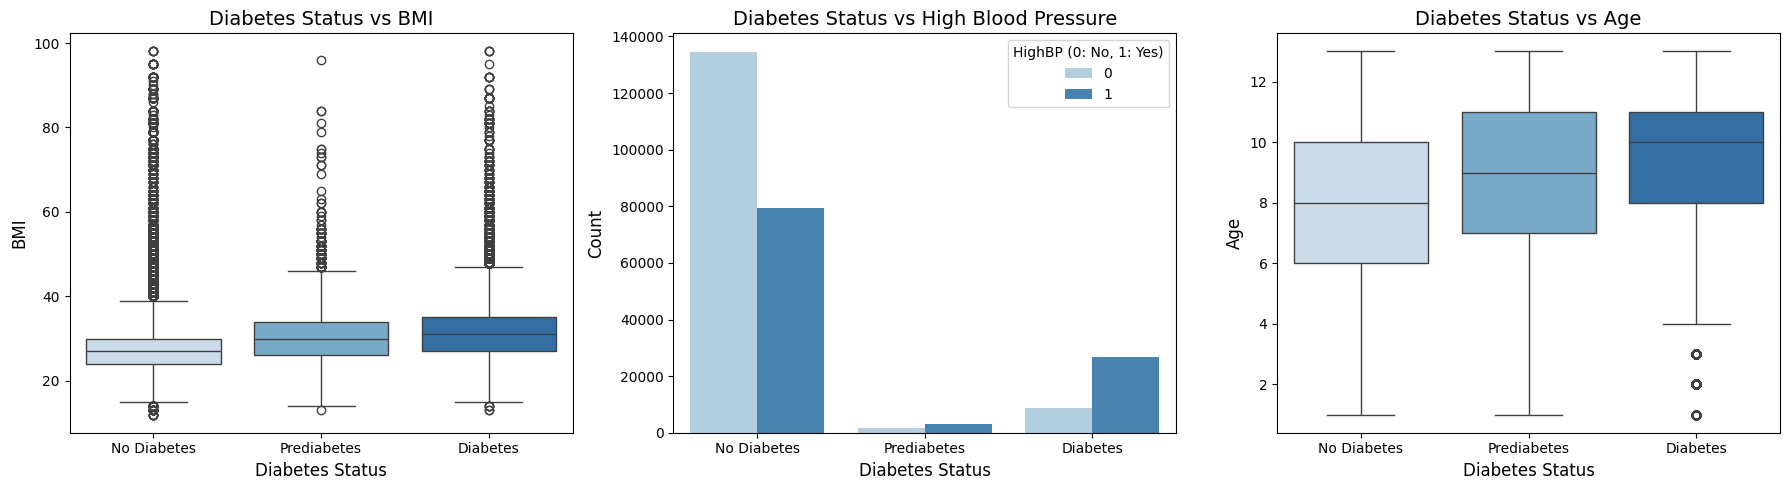

In [ ]:
# Bivariate analysis: Diabetes status vs BMI, HighBP, and Age

# Set up the figure
plt.figure(figsize=(18, 5))

# 1. Diabetes vs BMI
plt.subplot(1, 3, 1)
sns.boxplot(x='Diabetes_012', y='BMI', data=df, palette='Blues')
plt.title('Diabetes Status vs BMI', fontsize=14)
plt.xlabel('Diabetes Status', fontsize=12)
plt.ylabel('BMI', fontsize=12)
plt.xticks([0, 1, 2], ['No Diabetes', 'Prediabetes', 'Diabetes'])

# 2. Diabetes vs HighBP
plt.subplot(1, 3, 2)
sns.countplot(x='Diabetes_012', hue='HighBP', data=df, palette='Blues')
plt.title('Diabetes Status vs High Blood Pressure', fontsize=14)
plt.xlabel('Diabetes Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1, 2], ['No Diabetes', 'Prediabetes', 'Diabetes'])
plt.legend(title='HighBP (0: No, 1: Yes)', loc='upper right')

# 3. Diabetes vs Age
plt.subplot(1, 3, 3)
sns.boxplot(x='Diabetes_012', y='Age', data=df, palette='Blues')
plt.title('Diabetes Status vs Age', fontsize=14)
plt.xlabel('Diabetes Status', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.xticks([0, 1, 2], ['No Diabetes', 'Prediabetes', 'Diabetes'])

plt.tight_layout()
plt.show()


Chi-square test for Diabetes_012 vs HighBP: p-value = 0.0
ANOVA for Diabetes_012 vs BMI: p-value = 0.0


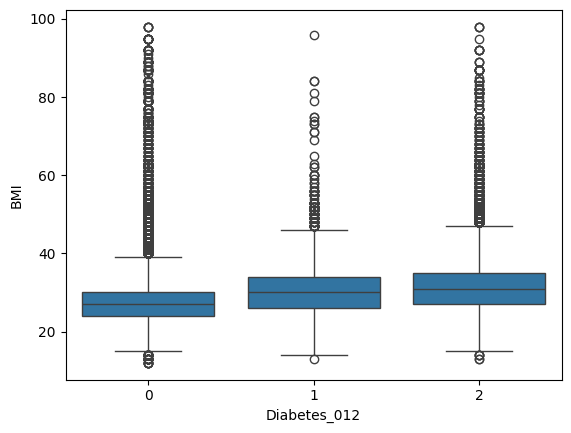

In [ ]:
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# Chi-square test for categorical variables
contingency_table = pd.crosstab(df['Diabetes_012'], df['HighBP'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square test for Diabetes_012 vs HighBP: p-value = {p}")

# ANOVA for continuous variables
groups = df['Diabetes_012'].unique()
bmi_by_group = [df['BMI'][df['Diabetes_012'] == g] for g in groups]
fvalue, pvalue = stats.f_oneway(*bmi_by_group)
print(f"ANOVA for Diabetes_012 vs BMI: p-value = {pvalue}")

# Visualization
sns.boxplot(x='Diabetes_012', y='BMI', data=df)
plt.show()